# Analyzing finetuned results

**USER INPUT REQUIRED**: Set the workspace folder to be your local workspace folder

In [1]:
import os
WORKSPACE_FOLDER=''
os.chdir(WORKSPACE_FOLDER)

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
import numpy as np

from analysis.finetuning_statistics import FinetuningStatistics
from utils import read_txt_to_list

### Load some statistics on your finetuning run

Loading sweeps
Evaluating performance


100%|██████████| 1/1 [00:00<00:00, 206.18it/s]


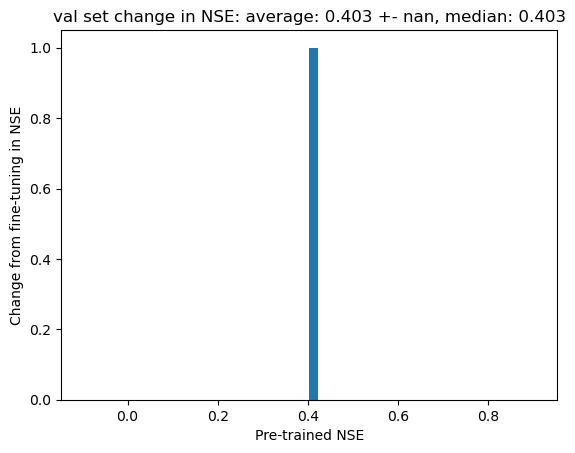

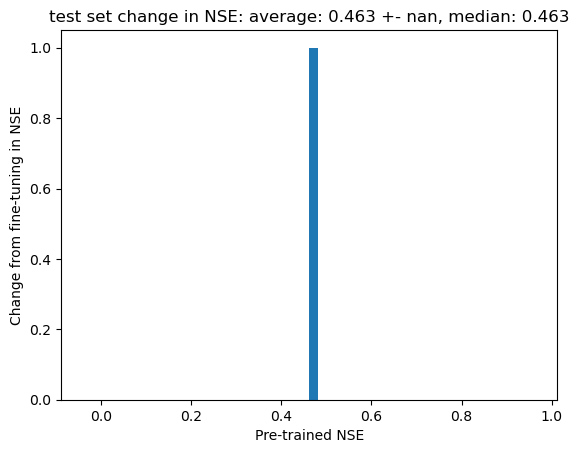

In [ ]:
# 1. USER INPUT REQUIRED: Add your experiment directory, basin file and experiment name
experiment_dir = Path('')
basin_file = Path('')
experiment_name = ''

# 2. find their score deltas with their base model
basins = read_txt_to_list(basin_file)
fs = FinetuningStatistics(sweep_name=experiment_name, experiment_path=experiment_dir, basins=basins)
df = fs.get_statistics()



### Examine the relationship between pre-trained skill score and finetuning improvement

In [3]:
# ok, let's check how improvements correlate with original skill
threshold = 0.0
x = df['test_origin']
y = df['test_delta'].loc[x > threshold]
x = x.loc[x > threshold]

/tmp/ipykernel_320166/3292172158.py:18: RankWarning: Polyfit may be poorly conditioned
  fit = np.polyfit(x, y, 1)
/home/admin/anaconda3/envs/neuralhydrology/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1211: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


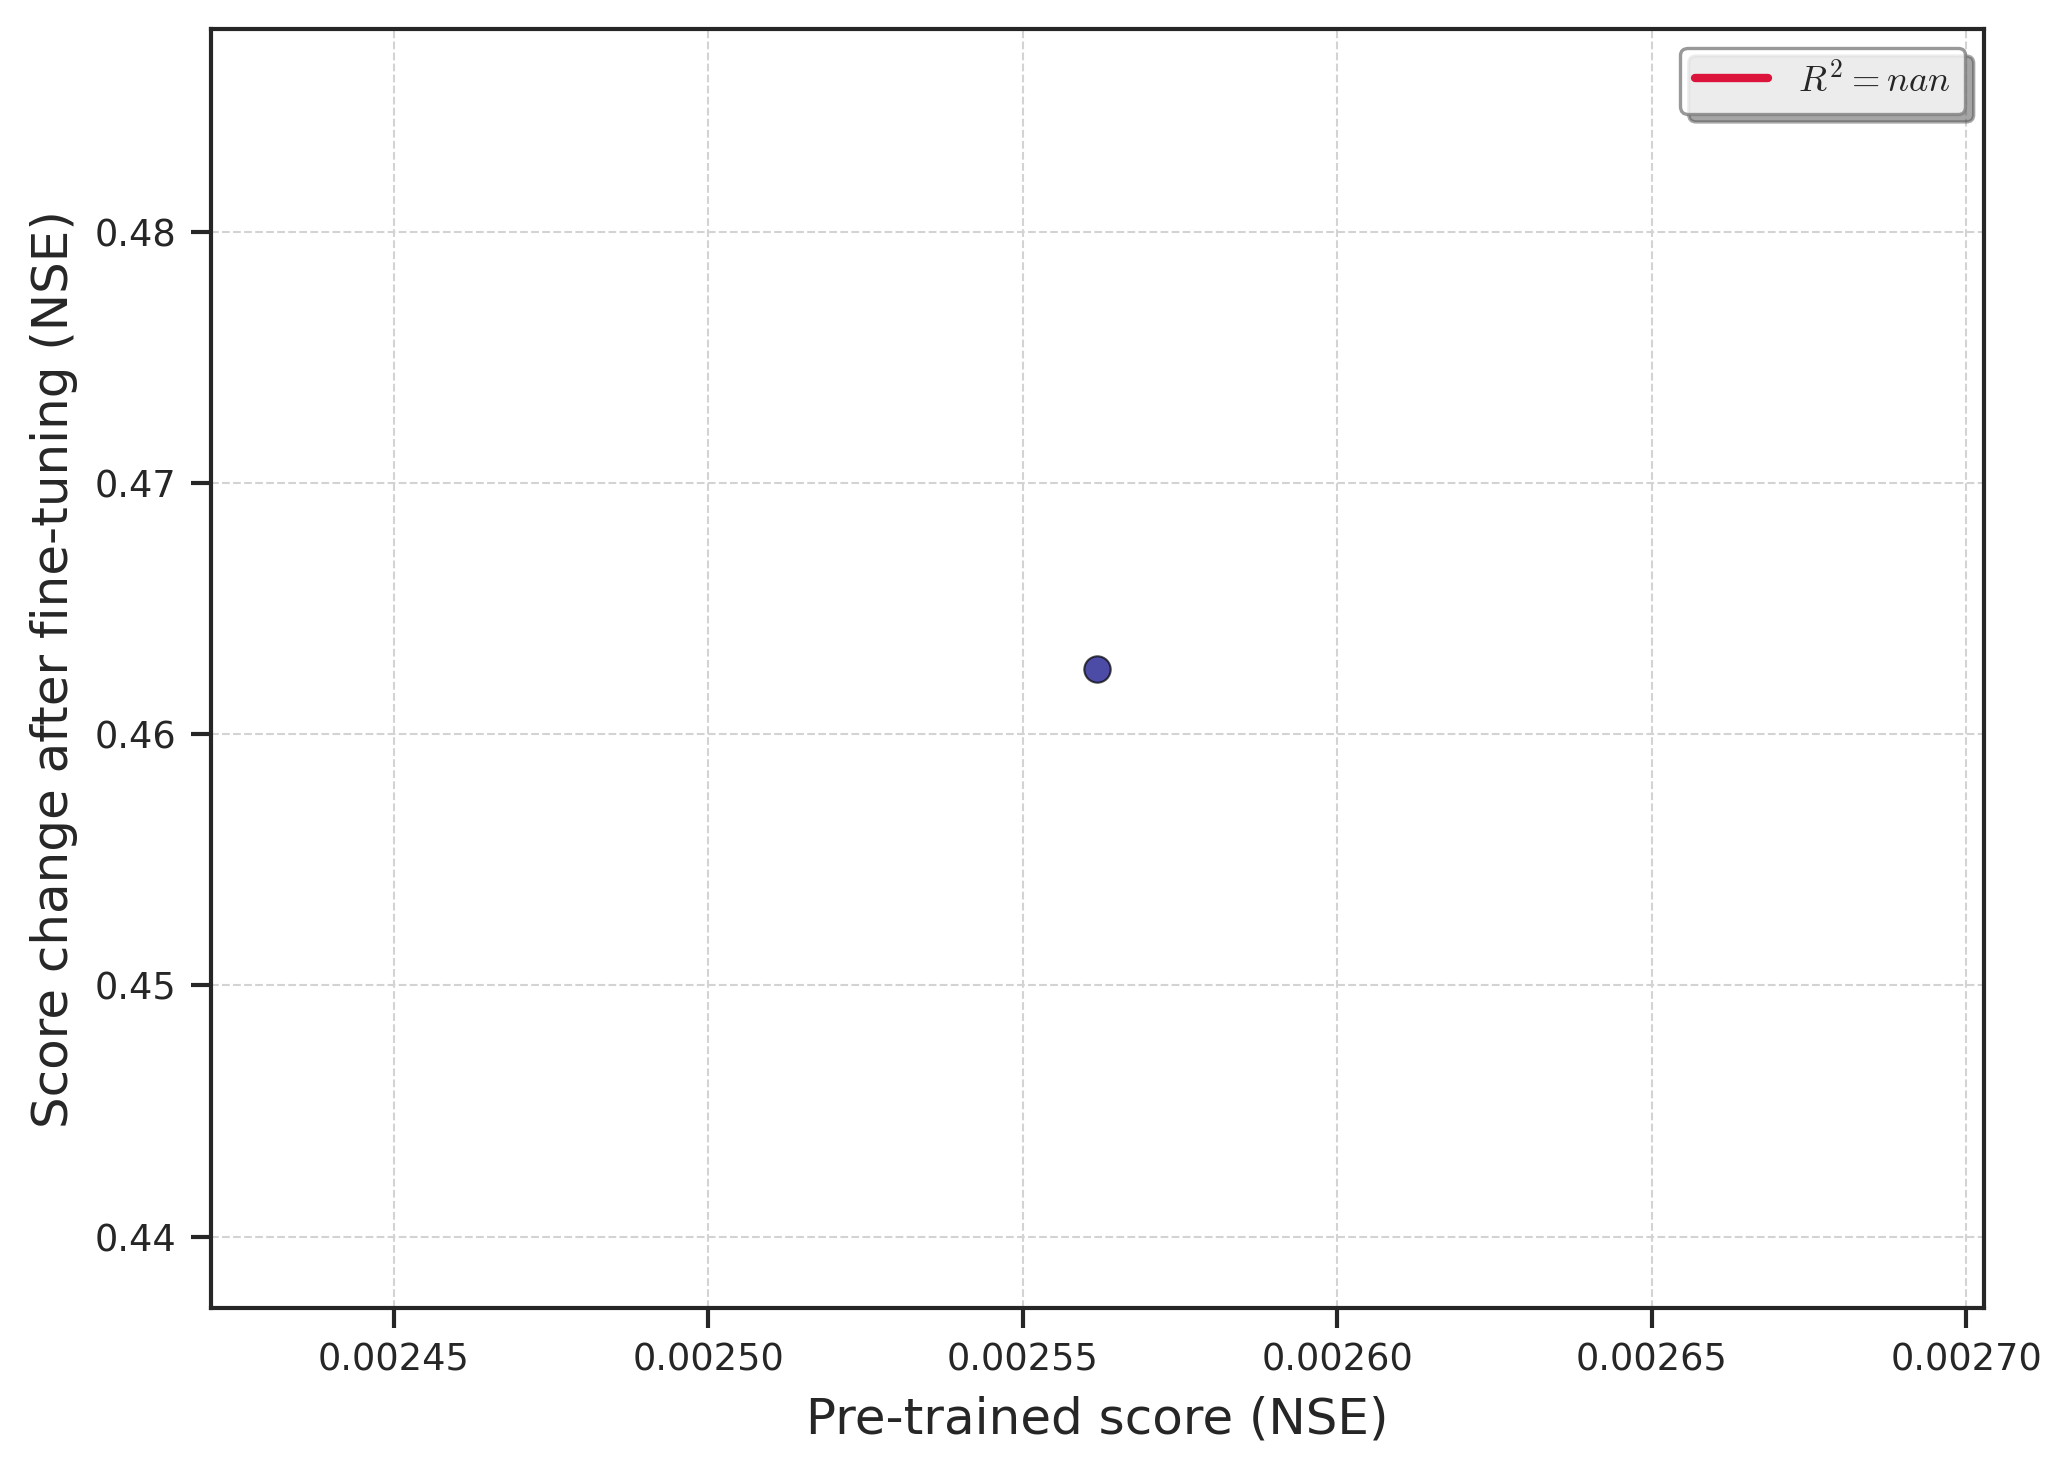

In [4]:
# Use a professional font (Times New Roman-like)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Set the style to mimic academic publication plots
plt.style.use('seaborn-v0_8-white')
sns.set_context('paper')

# Create the figure with publication-like dimensions
plt.figure(figsize=(7, 5), dpi=300)

# Scatter plot with professional styling
plt.scatter(x, y, alpha=0.7, color='navy', edgecolors='black', linewidth=0.5, 
            marker='o', s=40, zorder=1)

# Fitted line
fit = np.polyfit(x, y, 1)
y_pred = fit[0]*x + fit[1]

# Calculate R-squared
r_squared = r2_score(y, y_pred)

plt.plot(x, y_pred, color='crimson', linewidth=2, zorder=2,
         label=f'$R^2 = {r_squared:.3f}$')

# Styling for publication-like appearance
plt.xlabel('Pre-trained score (NSE)', fontsize=12)
plt.ylabel('Score change after fine-tuning (NSE)', fontsize=12)

# Enhanced legend
plt.legend(frameon=True, edgecolor='gray', loc='best', 
           framealpha=0.8, fancybox=True, shadow=True)

# Refined grid
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=0)
plt.tight_layout()

# Save with high resolution
plt.savefig('analysis/finetuning_delta_vs_pretrained_score.png', dpi=300, bbox_inches='tight')
plt.show()